## Problem Statement

### Business Context

The healthcare industry is rapidly evolving, with professionals facing increasing challenges in managing vast volumes of medical data while delivering accurate and timely diagnoses. The need for quick access to comprehensive, reliable, and up-to-date medical knowledge is critical for improving patient outcomes and ensuring informed decision-making in a fast-paced environment.

Healthcare professionals often encounter information overload, struggling to sift through extensive research and data to create accurate diagnoses and treatment plans. This challenge is amplified by the need for efficiency, particularly in emergencies, where time-sensitive decisions are vital. Furthermore, access to trusted, current medical information from renowned manuals and research papers is essential for maintaining high standards of care.

To address these challenges, healthcare centers can focus on integrating systems that streamline access to medical knowledge, provide tools to support quick decision-making, and enhance efficiency. Leveraging centralized knowledge platforms and ensuring healthcare providers have continuous access to reliable resources can significantly improve patient care and operational effectiveness.

**Common Questions to Answer**

**1. Diagnostic Assistance**: "What are the common symptoms and treatments for pulmonary embolism?"

**2. Drug Information**: "Can you provide the trade names of medications used for treating hypertension?"

**3. Treatment Plans**: "What are the first-line options and alternatives for managing rheumatoid arthritis?"

**4. Specialty Knowledge**: "What are the diagnostic steps for suspected endocrine disorders?"

**5. Critical Care Protocols**: "What is the protocol for managing sepsis in a critical care unit?"

### Objective

As an AI specialist, your task is to develop a RAG-based AI solution using renowned medical manuals to address healthcare challenges. The objective is to **understand** issues like information overload, **apply** AI techniques to streamline decision-making, **analyze** its impact on diagnostics and patient outcomes, **evaluate** its potential to standardize care practices, and **create** a functional prototype demonstrating its feasibility and effectiveness.

### Data Description

The **Merck Manuals** are medical references published by the American pharmaceutical company Merck & Co., that cover a wide range of medical topics, including disorders, tests, diagnoses, and drugs. The manuals have been published since 1899, when Merck & Co. was still a subsidiary of the German company Merck.

The manual is provided as a PDF with over 4,000 pages divided into 23 sections.

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

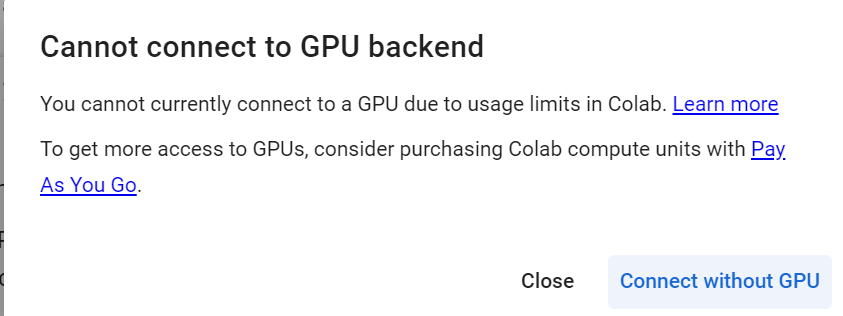

## Installing and Importing Necessary Libraries and Dependencies

In [8]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
#%CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
# %CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir -q


import os

# 1. Set the environment variables for the compiler
os.environ["CMAKE_ARGS"] = "-DGGML_CUDA=on"
os.environ["FORCE_CMAKE"] = "1"

# 2. Run the installation using the '!' shell escape
# We use {sys.executable} to ensure it installs into the correct virtual environment
import sys
!{sys.executable} -m pip install llama-cpp-python==0.2.28 --force-reinstall --no-cache-dir

     ---------------------------------------- 9.4/9.4 MB 28.5 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 44.6/44.6 kB ? eta 0:00:00
     --------------------------------------- 12.6/12.6 MB 81.8 MB/s eta 0:00:00
     ---------------------------------------- 45.5/45.5 kB ? eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.2.28-cp311-cp311-win_amd64.whl size=2800961 sha256=eeebbe123b2470a1b89e189aa81c041ed94047e395fecd9a40ce466b932d851a
  Stored in directory: C:\Users\JohnAraujo\AppData\Local\Temp\pip-ephem-wheel


[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [9]:
# For installing the libraries & downloading models from HF Hub
import sys
!{sys.executable} -m pip install huggingface_hub==0.35.3 pandas==2.2.2 tiktoken==0.12.0 pymupdf==1.26.5 langchain==0.3.27 langchain-community==0.3.31 chromadb==1.1.1 sentence-transformers==5.1.1 numpy==2.3.3 -q


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Downgrade to the highest versions that satisfy gensim's requirements
%pip install "numpy>=1.18.5,<2.0" "scipy>=1.7.0,<1.14.0"

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl (46.2 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.3.3

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-2.3.3:
   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-2.3.3
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   --------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [10]:
from llama_cpp import Llama

# Use the model downloaded in the notebook (or download it here if missing)
if "model_path" not in globals():
	from huggingface_hub import hf_hub_download
	model_path = hf_hub_download(
		repo_id="TheBloke/Mistral-7B-Instruct-v0.2-GGUF",
		filename="mistral-7b-instruct-v0.2.Q6_K.gguf"
	)

# n_gpu_layers=1 or higher requests GPU offloading
llm = Llama(model_path=model_path, n_gpu_layers=30)

offloaded_layers = getattr(getattr(llm, "params", None), "n_gpu_layers", 30)
print("Total layers offloaded to GPU:", offloaded_layers)

c:\Users\JohnAraujo\workspace\AustinUniversity\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total layers offloaded to GPU: 30


AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 0 | SSE3 = 1 | SSSE3 = 0 | VSX = 0 | 


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [11]:
#Libraries for downloading and loading the llm
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

In [12]:
from IPython.display import display, Markdown

## Question Answering using LLM

### Downloading and Loading the model

In [13]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"

In [14]:
model_path = hf_hub_download(
    repo_id= model_name_or_path, #Complete the code to mention the repo id
    filename= model_basename #Complete the code to mention the model name
)

In [15]:
#uncomment the below snippet of code if the runtime is connected to GPU.
llm = Llama(
    model_path=model_path,
    n_ctx=4000,
    n_gpu_layers=36,
    n_batch=512
)

AVX = 1 | AVX_VNNI = 0 | AVX2 = 1 | AVX512 = 0 | AVX512_VBMI = 0 | AVX512_VNNI = 0 | FMA = 1 | NEON = 0 | ARM_FMA = 0 | F16C = 1 | FP16_VA = 0 | WASM_SIMD = 0 | BLAS = 0 | SSE3 = 1 | SSSE3 = 0 | VSX = 0 | 


In [ ]:
#uncomment the below snippet of code if the runtime is connected to CPU only.
#llm = Llama(
#    model_path=model_path,
#    n_ctx=1024,
#    n_cores=-2
#)

### Response

In [16]:
def response(query,max_tokens=400,temperature=0.1,top_p=0.95,top_k=40):
    model_output = llm(
      prompt=query,
      max_tokens=max_tokens,
      temperature=temperature,
      top_p=top_p,
      top_k=top_k
    )

    return model_output['choices'][0]['text']

In [105]:
rslt = response("What treatment options are available for managing hypertension?")
display(Markdown(rslt))

Llama.generate: prefix-match hit




Hypertension, or high blood pressure, is a common condition that can increase the risk of various health problems such as heart disease, stroke, and kidney damage. The good news is that there are several effective treatment options available to help manage hypertension and reduce the risk of complications. Here are some of the most commonly used treatments:

1. Lifestyle modifications: Making lifestyle changes is often the first line of defense against hypertension. This may include eating a healthy diet rich in fruits, vegetables, whole grains, lean proteins, and low-fat dairy products; limiting sodium intake; getting regular physical activity; maintaining a healthy weight; and reducing stress through techniques such as meditation, deep breathing, or yoga.
2. Medications: If lifestyle modifications alone are not enough to control hypertension, medications may be necessary. There are several classes of drugs used to treat hypertension, including diuretics, beta blockers, ACE inhibitors, calcium channel blockers, and ARBs (angiotensin receptor blockers). These medications work by reducing the amount of blood your heart pumps and/or the amount of fluid in your body, which helps to lower blood pressure.
3. Combination therapy: In some cases, a combination of lifestyle modifications and medications may be necessary to effectively manage hypertension. Your healthcare provider may recommend a specific combination of treatments based on your individual needs and health condition.
4. Alternative therapies: There are also several alternative therapies that have been shown to help lower blood pressure, although more research is needed to fully understand their effectiveness. These include acupuncture, chiropractic care, herbal supplements (such as garlic or hibiscus), and mind-body techniques such as meditation and deep breathing exercises.
5. Lifestyle modifications for specific conditions: In some cases, hypertension may be caused by an underlying condition such as kidney disease or sleep apnea. In these cases, treating the underlying condition may help to lower blood pressure. For example, managing kidney disease with dialysis or a transplant, or using a continuous positive airway pressure (CPAP) machine to treat sleep apnea, can all help to reduce blood pressure.

It's important to note that everyone's body responds differently to different treatments, so it may take some

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [106]:
user_input_1 = "What is the protocol for managing sepsis in a critical care unit?"
rslt = response(user_input_1)
display(Markdown(rslt))

Llama.generate: prefix-match hit




Sepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:

1. Early recognition and suspicion: Septic patients may present with non-specific symptoms such as fever, chills, tachycardia, tachypnea, altered mental status, or lactic acidosis. It is essential to have a high index of suspicion for sepsis in patients with suspected or confirmed infection.
2. Early goal-directed therapy (EGDT): EGDT is a protocolized approach to managing sepsis that aims to optimize hemodynamic parameters and improve organ perfusion. The components of EGDT include:
   - Maintaining mean arterial pressure (MAP) ≥65 mmHg
   - Central venous oxygen saturation (ScvO2) ≥70%
   - Urine output ≥0.5 mL/kg/h
3. Source control: Identify and address the source of infection as soon as possible. This may involve surgical intervention, drainage, or debridement.
4. Antimicrobial therapy: Administer broad-spectrum antimicrobials based on the suspected infectious organism(s) and local antibiogram data.
5. Fluid resuscitation: Aggressively replace fluids to maintain adequate tissue perfusion. Crystalloids, colloids, or blood products may be used depending on the patient's hemodynamic status.
6. Vasopressor support: If the patient requires vasopressors to maintain MAP ≥65 mmHg, consider adding a vasopressin infusion to optimize cardiac output and reduce the need for high doses of catecholamines.
7. Corticosteroids: Consider using corticosteroids in patients with septic shock who do not respond to initial fluid resuscitation and vasopressor therapy.
8. Inotropic support: If the patient has low cardiac output despite adequate fluid resuscitation, consider adding an inotrope or vasoactive agent to improve contractility and/or peripheral vascular tone.
9. Renal

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [107]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to define the query #2
rslt = response(user_input_2) #Complete the code to pass the user input #2
display(Markdown(rslt))

Llama.generate: prefix-match hit




Appendicitis is a medical condition characterized by inflammation of the appendix, a small tube-shaped organ located in the lower right side of the abdomen. The symptoms of appendicitis can vary from person to person, but some common signs include:

1. Abdominal pain: The pain typically starts as a mild discomfort around the navel or in the lower right abdomen and may progress to a sharp, localized pain in the right lower quadrant of the abdomen.
2. Loss of appetite: People with appendicitis often lose their appetite due to abdominal pain and discomfort.
3. Nausea and vomiting: Vomiting is a common symptom of appendicitis, especially as the condition progresses.
4. Fever: A fever may be present in some cases of appendicitis.
5. Constipation or diarrhea: Both constipation and diarrhea can occur with appendicitis.
6. Rebound tenderness: When pressure is applied to the abdomen, there may be pain or tenderness that disappears when the pressure is released (rebound tenderness).
7. Guarding: People with appendicitis may involuntarily contract their abdominal muscles to protect the area from further discomfort.
8. Rigidity: The abdominal muscles may become rigid and difficult to move, especially in the lower right quadrant of the abdomen.

Appendicitis cannot be cured with medicine alone. Antibiotics may be used to treat any accompanying bacterial infection, but they do not address the underlying inflammation or appendix itself. Surgery is the only effective treatment for appendicitis. The most common surgical procedure for treating appendicitis is an appendectomy, which involves removing the appendix through a small incision in the abdomen. This procedure can be performed laparoscopically (using small incisions and a camera) or open (with a larger incision).

It's essential to seek medical attention promptly if you suspect appendicitis, as delaying treatment can lead to complications such as rupture of the appendix, peritonitis (inflammation of the abdominal cavity), and sepsis (a potentially life-threatening infection).

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [108]:
user_input_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to define the query #3
rslt = response(user_input_3) #Complete the code to pass the user input #3
display(Markdown(rslt))

Llama.generate: prefix-match hit




Sudden patchy hair loss, also known as alopecia areata, is a common autoimmune disorder that affects the hair follicles. It can result in round or oval bald patches on the scalp, but it can also occur on other parts of the body such as the beard area, eyebrows, and eyelashes.

The exact cause of alopecia areata is not known, but it's believed to be related to a problem with the immune system. Some possible triggers for this condition include stress, genetics, viral infections, and certain medications.

There are several treatments that have been shown to be effective in managing alopecia areata:

1. Corticosteroids: These are anti-inflammatory drugs that can help reduce inflammation and suppress the immune system's attack on the hair follicles. They can be applied topically or taken orally, depending on the severity of the condition.
2. Minoxidil: This is a medication that has been shown to promote hair growth in some people with alopecia areata. It works by increasing blood flow to the affected area and stimulating hair follicles to produce new hairs.
3. DHT blockers: Dihydrotestosterone (DHT) is a hormone that can contribute to hair loss. Some people with alopecia areata have high levels of DHT in their scalp. Finasteride and dutasteride are medications that can block the production of DHT, which may help promote hair growth.
4. Immunotherapy: This involves using substances that stimulate an immune response to help the body fight off the attack on the hair follicles. One such substance is anthralin, which can be applied topically. Another option is JAK inhibitors, which are oral medications that have shown promise in clinical trials for treating alopecia areata.
5. Hair transplantation: In some cases, hair transplantation may be an option for people with extensive hair loss due to alopecia areata. This involves taking healthy hairs from another part of the scalp or body and implanting them into the bald areas.
6. Lifestyle modifications: Certain lifestyle factors can contribute to hair loss, such as stress, poor nutrition, and lack

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [109]:
user_input_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to define the query #4
rslt = response(user_input_4) #Complete the code to pass the user input #4
display(Markdown(rslt))

Llama.generate: prefix-match hit




A person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function, is typically diagnosed with a traumatic brain injury (TBI). The treatment for TBI depends on the severity and location of the injury. Here are some common treatments recommended for individuals with TBI:

1. Emergency care: In case of a severe TBI, the first priority is to provide emergency care to ensure the person's airway is clear, breathing is stable, and circulation is adequate. This may involve intubation, administering oxygen, and controlling bleeding.
2. Medications: Depending on the symptoms, healthcare professionals may prescribe medications to manage conditions such as seizures, pain, or swelling in the brain. For instance, anti-inflammatory drugs like corticosteroids may be given to reduce inflammation and prevent further damage.
3. Surgery: In some cases, surgery may be necessary to remove blood clots or repair skull fractures that could be putting pressure on the brain. Craniotomy, a surgical procedure to remove a portion of the skull, may also be performed to relieve swelling or allow for the brain to expand.
4. Rehabilitation: Rehabilitation is an essential part of the treatment process for individuals with TBI. This can include physical therapy to help regain mobility and strength, occupational therapy to learn new skills or adapt to limitations, speech-language therapy to improve communication abilities, and cognitive rehabilitation to address memory, attention, and problem-solving deficits.
5. Assistive devices: Depending on the extent of the injury, individuals with TBI may require assistive devices such as wheelchairs, walkers, or braces to help them move around. They might also need communication aids like text-to-speech software or picture boards to facilitate communication.
6. Support groups and counseling: Living with a brain injury can be challenging both for the individual and their family members. Joining support groups and seeking counseling can help individuals cope with the emotional and psychological aspects of their injury, as well as provide opportunities to connect with others who have gone through similar experiences.
7. Lifestyle modifications: Making lifestyle modifications such as getting enough rest, eating a healthy diet, avoiding alcohol and drugs, and engaging in regular physical activity can help

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [110]:
user_input_5 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to define the query #5
rslt=response(user_input_5) #Complete the code to pass the user input #5
display(Markdown(rslt))

Llama.generate: prefix-match hit




First and foremost, it is essential to ensure the safety of the injured person and any companions. If possible, try to keep the person as comfortable as possible while assessing the extent of the injury. Here are some general steps to follow:

1. Assess the severity of the injury: Check for signs of open wounds, swelling, deformity, or inability to move the leg. If there is significant pain, swelling, or deformity, it may be a fracture. However, only a medical professional can make an accurate diagnosis.
2. Immobilize the leg: Use a splint, sling, or other available materials to immobilize the leg as best as possible. This will help prevent further injury and provide some comfort to the person.
3. Provide first aid: Clean any wounds with water and gentle soap, apply pressure to control bleeding, and cover the wound with a sterile dressing.
4. Monitor vital signs: Check the person's pulse, respiration rate, and level of consciousness regularly. If their condition worsens or they exhibit signs of shock (pale skin, rapid heartbeat, weak pulse), seek medical help immediately.
5. Seek medical attention: It is crucial to get the person to a healthcare facility as soon as possible for proper diagnosis and treatment. This may involve transporting them by foot, horseback, or other means if they are unable to walk.
6. Consider the care and recovery process: Depending on the severity of the fracture, the person may require surgery, extended hospitalization, or rehabilitation. They will likely need to avoid weight-bearing activities for an extended period, which could impact their ability to hike or engage in other physical activities. It is essential to provide emotional support and help with daily tasks during this time.
7. Prepare for future hiking trips: Consider the risks involved in hiking and take steps to minimize them. This may include carrying a well-stocked first aid kit, wearing appropriate footwear and clothing, and staying informed about weather conditions and trail conditions. Additionally, consider taking a wilderness first aid course to learn how to handle emergencies in remote areas.

## Question Answering using LLM with Prompt Engineering

In [ ]:
# system_prompt = """You are a professional Medical AI Assistant. 
# Your goal is to support healthcare professionals by providing accurate, evidence-based information retrieved from trusted medical manuals.

# Strict Guidelines:
# 1. Grounding: Use ONLY the provided context to answer the question. If the answer is not in the context, state that you do not have enough information.
# 2. Accuracy: Provide precise clinical protocols, dosages, and diagnostic steps as they appear in the source.
# 3. Tone: Maintain a professional, objective, and clinical tone.
# 4. Conciseness: Avoid conversational filler. Provide direct answers to help clinicians make time-sensitive decisions in fast-paced environments.
# 5. Safety: If a situation is described as a medical emergency (e.g., sepsis or appendicitis), prioritize the immediate life-saving steps first.""" #Complete the code to define the system prompt

In [111]:
system_prompt = """ 
You are a professional Medical AI Assistant for healthcare professionals.

Rules:
1. Use ONLY the provided context. Do not use outside knowledge. If the answer is not in the context, say: "Insufficient information in provided source."
2. Be accurate. Provide protocols, dosages, diagnostic steps, and treatments exactly as supported by the source.
3. Use a professional, objective, concise clinical tone.
4. Prioritize speed and clarity for time-sensitive settings.
5. If critical data for safe treatment is missing (age, weight, allergies, pregnancy, renal/hepatic status), state what is needed.
6. If the case suggests an emergency (sepsis, stroke, appendicitis, anaphylaxis, airway issue), give immediate life-saving actions first, then diagnostics, then treatment.
7. Do not guess or invent information.

Preferred Response Format:
- Assessment
- Immediate Actions
- Diagnostics
- Treatment
- Warnings / Escalation
"""


### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [112]:
user_input_1 = system_prompt+"\n"+ "What is the protocol for managing sepsis in a critical care unit?"
rslt=response(user_input_1)
display(Markdown(rslt))

Llama.generate: prefix-match hit




Assessment:
1. Identify signs and symptoms of sepsis, including fever or hypothermia, tachycardia or bradycardia, respiratory distress, altered mental status, and lactic acidosis.
2. Evaluate severity using the Sequential [Sepsis-related] Organ Failure Assessment (SOFA) score.
3. Check for source of infection.
4. Assess fluid status and consider volume resuscitation.
5. Evaluate hemodynamic stability.
6. Monitor electrolytes, glucose, and acid-base balance.
7. Assess respiratory function and provide oxygen support as needed.
8. Check for coagulopathy and administer appropriate blood products if necessary.
9. Monitor cardiac function and provide inotropic support if needed.
10. Evaluate renal function and consider diuretics or continuous renal replacement therapy (CRRT).
11. Assess neurologic status and provide supportive care as needed.

Immediate Actions:
1. Administer high-flow oxygen via non-rebreather mask or endotracheal tube if respiratory distress is present.
2. Initiate intravenous access and administer 30 mL/kg of crystalloid solution over the first hour, followed by 3 mL/kg/h for the next few hours.
3. Administer broad-spectrum antibiotics based on suspected infection site and local microbiology data.
4. Initiate vasopressor therapy if mean arterial pressure (MAP) is less than 65 mmHg despite adequate fluid resuscitation.
5. Consider administering corticosteroids in cases of septic shock unresponsive to initial fluid resuscitation and vasopressors.

Diagnostics:
1. Obtain blood cultures before antibiotic administration if possible.
2. Perform complete blood count, coagulation panel, electrolytes, glucose, lactate, and arterial blood gases.
3. Consider obtaining urinalysis, chest X-ray, and other imaging studies as needed based on clinical presentation.
4. Monitor serial SOFA scores to assess organ dysfunction.

Treatment:
1. Contin

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [113]:
user_input_2 = system_prompt+"\n"+ "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
rslt=response(user_input_2) #Complete the code to pass the user input #2
display(Markdown(rslt))

Llama.generate: prefix-match hit




Assessment:
The context does not provide sufficient information about specific symptoms or whether appendicitis can be cured with medication. However, common symptoms of appendicitis include abdominal pain (usually localized in the right lower quadrant), loss of appetite, nausea and vomiting, fever, and rebound tenderness.

Immediate Actions:
If there is suspicion of appendicitis, consider it a surgical emergency due to potential rupture and peritonitis. Immediately initiate broad-spectrum antibiotics for sepsis prophylaxis. Secure intravenous access and prepare for possible surgery.

Diagnostics:
Confirm the diagnosis with imaging studies such as ultrasound or CT scan. A positive finding of an inflamed appendix with a diameter greater than 6mm, periappendiceal fat stranding, and free fluid in the right lower quadrant is indicative of appendicitis.

Treatment:
The standard treatment for appendicitis is surgical removal of the appendix (appendectomy). This can be performed as an open procedure or laparoscopically, depending on the patient's condition and surgeon's preference. Post-operative care includes pain management, antibiotics to treat any existing infection, and monitoring for complications such as wound infection or post-operative ileus.

Warnings / Escalation:
If there is a delay in diagnosis or treatment of appendicitis, the appendix may rupture, leading to peritonitis, sepsis, and potential organ failure. In this case, immediate surgical intervention is required to prevent further complications. Additionally, consider other differential diagnoses such as Crohn's disease, diverticulitis, or ectopic pregnancy when evaluating patients with suspected appendicitis.

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [114]:
user_input_3 =  system_prompt+"\n"+ "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"  #Complete the code to pass the query #3
rslt=response(user_input_3) #Complete the code to pass the user input #3
display(Markdown(rslt))

Llama.generate: prefix-match hit




Context:
A 35-year-old female patient presents with a concern about sudden patchy hair loss. She describes the issue as localized bald spots on her scalp that have appeared over the past few weeks. The patches are round in shape, approximately 1 inch in diameter, and seem to be spreading slowly. She denies any recent stressors or significant life changes. Her medical history is unremarkable, with no known allergies or autoimmune disorders.

Assessment:
The patient's symptoms suggest a form of alopecia areata, an autoimmune disorder causing patchy hair loss. The round bald spots and slow spreading indicate the early stages of this condition.

Immediate Actions:
None required at this time as the issue does not pose an immediate threat to the patient's health or safety.

Diagnostics:
A scalp biopsy may be performed to confirm the diagnosis of alopecia areata. Other diagnostic tests, such as a complete blood count (CBC), thyroid function tests, and autoimmune panels, can help rule out other causes of hair loss.

Treatment:
Topical treatments like minoxidil or corticosteroids may be prescribed to promote hair regrowth in the affected areas. Intra-lesional corticosteroid injections can also be considered for more severe cases. Systemic treatments, such as oral corticosteroids or immunosuppressants, may be recommended if the condition affects a large area of the scalp or causes significant psychological distress.

Warnings / Escalation:
Monitor the patient's progress and assess the need for escalating treatment based on the size and number of bald patches, as well as the patient's emotional response to the condition. If the condition worsens or spreads rapidly, consider referring the patient to a dermatologist for further evaluation and potential systemic treatments. Additionally, if the patient reports any new symptoms or signs of infection in the affected areas, seek medical attention promptly.

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [115]:
user_input_4 = system_prompt+"\n"+ "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
rslt=response(user_input_4) #Complete the code to pass the user input #4
display(Markdown(rslt))

Llama.generate: prefix-match hit




Assessment:
The provided context does not specify the extent or nature of the brain injury. It is essential to assess the level of consciousness, pupil response, motor function, and vital signs. If there are signs of increased intracranial pressure (ICP), such as headache, vomiting, altered mental status, or decreased level of consciousness, consider it a medical emergency.

Immediate Actions:
1. Ensure the airway is clear and secure.
2. Monitor vital signs closely.
3. Provide oxygen supplementation if necessary.
4. Control any bleeding if present.
5. Administer glucose if the patient is unconscious or unresponsive.
6. If there are signs of increased ICP, consider administering mannitol or hyperventilation to reduce ICP.
7. If the patient is not breathing, initiate cardiopulmonary resuscitation (CPR).

Diagnostics:
1. Obtain a detailed history from the patient or family members if possible.
2. Perform a physical examination focusing on neurological assessment.
3. Order imaging studies such as CT scan or MRI to evaluate the extent and location of brain injury.
4. Consider obtaining laboratory tests, including complete blood count (CBC), coagulation panel, glucose level, and toxicology screen if indicated.
5. Consult with a neurologist or neurosurgeon for further evaluation and management.

Treatment:
1. Provide supportive care, such as maintaining adequate hydration, nutrition, and preventing complications like infections.
2. Administer medications to manage symptoms, such as analgesics for pain, anticonvulsants for seizures, or diuretics for increased ICP.
3. Consider surgical intervention if there is a mass lesion, hematoma, or herniation causing brain compression.
4. Provide rehabilitation services, including physical therapy, occupational therapy, and speech therapy, to help the patient regain lost functions.
5. Monitor the patient closely for any changes in condition and adjust treatment accordingly.

Warnings / Escalation:
1. If there are signs of increased ICP or impending herniation (unequal pupils, decreased level of consciousness, motor deficits), consider intubating

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [116]:
user_input_5 = system_prompt+"\n"+ "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
rslt= response(user_input_5) #Complete the code to pass the user input #5
display(Markdown(rslt))

Llama.generate: prefix-match hit




Assessment:
A leg fracture is a common injury in hiking due to uneven terrain and falls. The assessment of a person with a suspected leg fracture includes evaluating the following:
1. Location and severity of pain
2. Swelling, deformity, or open wounds
3. Ability to bear weight
4. Presence of neurovascular deficits (pulse, sensation)
5. Any associated injuries

Immediate Actions:
1. Ensure the safety of both the patient and rescuers.
2. Immobilize the affected leg using a splint or a sling to prevent further injury and maintain alignment.
3. Provide pain relief with non-narcotic analgesics, such as acetaminophen or ibuprofen, if no contraindications exist.
4. Administer oxygen if there are signs of respiratory distress.
5. Monitor vital signs and assess for any other injuries.
6. Transport the patient to a healthcare facility as soon as possible.

Diagnostics:
1. X-ray imaging is the gold standard for diagnosing leg fractures.
2. If there is suspicion of an open fracture, obtain cultures and initiate antibiotic therapy promptly.
3. Consider additional diagnostic tests if there are signs of associated injuries or complications (e.g., head injury, cardiac symptoms).

Treatment:
1. Once the diagnosis is confirmed, immobilize the leg using a cast or a brace to maintain alignment and promote healing.
2. Administer pain medication as needed for comfort.
3. Encourage early mobility and range of motion exercises under medical supervision to prevent complications such as stiffness and blood clots.
4. Monitor the patient's progress closely, including wound healing, bone healing, and functional recovery.
5. Consider referral to a specialist (orthopedic surgeon) for complex fractures or those that do not respond to conservative treatment.

Warnings / Escalation:
1. If there are signs of an open fracture, neurovascular deficits, severe pain, or inability to bear weight, consider this a medical emergency and seek immediate professional help.
2. In cases of suspected compartment syndrome (pain out of proportion to injury, swelling,

## Data Preparation for RAG

In [17]:
#Libraries for processing dataframes,text
import json,os
import tiktoken
import pandas as pd

#Libraries for Loading Data, Chunking, Embedding, and Vector Databases
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma

### Loading the Data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [18]:
manual_pdf_path = "medical_diagnosis_manual2.pdf" #Complete the code to define the file name

In [19]:
from pathlib import Path
# 1. Get the directory where the notebook is running
current_dir = Path.cwd()
pdf_loader = PyMuPDFLoader(current_dir / manual_pdf_path)

In [20]:
manual = pdf_loader.load()

### Data Overview

#### Checking the first 5 pages

In [22]:
for i in range(5):
    print(f"Page Number : {i+1}",end="\n")
    print(manual[i].page_content,end="\n")

Page Number : 1
daraujoao@gmail.com
873P5R0DSW
This file is meant for personal use by daraujoao@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 2
daraujoao@gmail.com
873P5R0DSW
This file is meant for personal use by daraujoao@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.
Page Number : 3
Table of Contents
1
Front    ................................................................................................................................................................................................................
1
Cover    .......................................................................................................................................................................................................
2
Front Matter    .......................................................................................................................................

#### Checking the number of pages

In [23]:
len(manual)

4114

### Data Chunking

In [24]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=900, #Complete the code to define the chunk size
    chunk_overlap= 120 #Complete the code to define the chunk overlap
)

In [25]:
document_chunks = pdf_loader.load_and_split(text_splitter)

In [77]:
len(document_chunks)

5457

In [26]:
print(document_chunks[0].page_content)

daraujoao@gmail.com
873P5R0DSW
This file is meant for personal use by daraujoao@gmail.com only.
Sharing or publishing the contents in part or full is liable for legal action.


In [27]:
print(document_chunks[3].page_content)

491
Chapter 44. Foot & Ankle Disorders    .....................................................................................................................................
502
Chapter 45. Tumors of Bones & Joints    ...............................................................................................................................
510
5 - Ear, Nose, Throat & Dental Disorders    ..................................................................................................................
510
Chapter 46. Approach to the Patient With Ear Problems    ...........................................................................................
523
Chapter 47. Hearing Loss    .........................................................................................................................................................
535
Chapter 48. Inner Ear Disorders    ...............................................................................................................

In [28]:
print(document_chunks[4].page_content)

861
Chapter 88. Pressure Ulcers    ...................................................................................................................................................
867
Chapter 89. Benign Tumors    .....................................................................................................................................................
874
Chapter 90. Cancers of the Skin    ............................................................................................................................................
882
8 - Endocrine & Metabolic Disorders    .............................................................................................................................
882
Chapter 91. Principles of Endocrinology    ............................................................................................................................
887
Chapter 92. Pituitary Disorders    ..........................................................................

As expected, there are some overlaps

### Embedding

In [31]:
embedding_model = SentenceTransformerEmbeddings(model_name="BAAI/bge-m3") #Complete the code to define the model name
#embedding_model = SentenceTransformerEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


In [32]:
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)

In [33]:
print("Dimension of the embedding vector ",len(embedding_1))
len(embedding_1)==len(embedding_2)

Dimension of the embedding vector  1024


True

In [34]:
embedding_1,embedding_2

([-0.03934742137789726,
  0.019992168992757797,
  -0.03968020901083946,
  -0.009551679715514183,
  -0.03103496879339218,
  -0.037712376564741135,
  0.03150884062051773,
  -0.009096331894397736,
  -0.0041671693325042725,
  -0.014839314855635166,
  0.016114840283989906,
  0.03707093000411987,
  -0.027460619807243347,
  -0.01861479878425598,
  -0.013076615519821644,
  0.02364133670926094,
  -0.004736218601465225,
  0.0026586796157062054,
  -0.029928889125585556,
  -0.032418277114629745,
  0.0018313305918127298,
  0.004522324074059725,
  0.01940956525504589,
  -0.004589120391756296,
  -0.01696058362722397,
  0.024084433913230896,
  0.02482486143708229,
  -0.019769057631492615,
  0.020225562155246735,
  -0.02837431989610195,
  0.010775239206850529,
  -0.018124375492334366,
  0.06216488778591156,
  -0.02025330625474453,
  -0.00840478390455246,
  -0.04048518091440201,
  -0.01705196313560009,
  -0.0129828667268157,
  -0.04951806366443634,
  -0.005132982507348061,
  0.039722319692373276,
  0.01

### Vector Database

In [35]:
os.getcwd()

'c:\\Users\\JohnAraujo\\workspace\\AustinUniversity\\05-nlp-with-genai\\Medical Assistant'

In [36]:
out_dir = 'medical_db'

if not os.path.exists(out_dir):
  os.makedirs(out_dir)

In [37]:
if os.path.exists(os.path.join(out_dir, 'chroma.sqlite3')):
    vectorstore = Chroma(persist_directory=out_dir, embedding_function=embedding_model)
    print(f"Loaded existing vectorstore with {vectorstore._collection.count()} documents")
else:
    vectorstore = Chroma.from_documents(
        document_chunks, #Complete the code to pass the document chunks
        embedding_model, #Complete the code to pass the embedding model
        persist_directory=out_dir
    )
    print(f"Created new vectorstore with {vectorstore._collection.count()} documents")

C:\Users\JohnAraujo\AppData\Local\Temp\ipykernel_15148\450505523.py:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(persist_directory=out_dir, embedding_function=embedding_model)


Loaded existing vectorstore with 5457 documents


In [38]:
len(document_chunks)

5457

In [39]:
vectorstore = Chroma(persist_directory=out_dir,embedding_function=embedding_model)

In [40]:
vectorstore.embeddings

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 8192, 'do_lower_case': False, 'architecture': 'XLMRobertaModel'})
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='BAAI/bge-m3', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [41]:
vectorstore.similarity_search("What is the protocol for managing sepsis in a critical care unit?",k=5) #Complete the code to pass a query and an appropriate k value

[Document(metadata={'moddate': '2026-04-26T11:42:58-04:00', 'creator': 'Atop CHM to PDF Converter', 'format': 'PDF 1.7', 'creationDate': 'D:20120615054440Z', 'page': 2456, 'total_pages': 4114, 'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'author': '', 'subject': '', 'trapped': '', 'source': 'c:\\Users\\JohnAraujo\\workspace\\AustinUniversity\\05-nlp-with-genai\\Medical Assistant\\medical_diagnosis_manual2.pdf', 'file_path': 'c:\\Users\\JohnAraujo\\workspace\\AustinUniversity\\05-nlp-with-genai\\Medical Assistant\\medical_diagnosis_manual2.pdf', 'keywords': '', 'modDate': "D:20260426114258-04'00'", 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'creationdate': '2012-06-15T05:44:40+00:00'}, page_content="Parenteral antibiotics should be given after specimens of blood, body fluids, and wound sites have been\ntaken for Gram stain and culture. Very prompt empiric therapy, started immediately after suspecting\nsepsis, is essential and may be lifesaving. Anti

### Retriever

In [42]:
retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 5} #Complete the code to pass an appropriate k value
)

In [43]:
query = "What is the protocol for managing sepsis in a critical care unit?"
rel_docs = retriever.get_relevant_documents(query) #Complete the code to pass the query
rel_docs

C:\Users\JohnAraujo\AppData\Local\Temp\ipykernel_15148\3999121553.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  rel_docs = retriever.get_relevant_documents(query) #Complete the code to pass the query


[Document(metadata={'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'subject': '', 'creator': 'Atop CHM to PDF Converter', 'modDate': "D:20260426114258-04'00'", 'creationdate': '2012-06-15T05:44:40+00:00', 'creationDate': 'D:20120615054440Z', 'source': 'c:\\Users\\JohnAraujo\\workspace\\AustinUniversity\\05-nlp-with-genai\\Medical Assistant\\medical_diagnosis_manual2.pdf', 'page': 2456, 'file_path': 'c:\\Users\\JohnAraujo\\workspace\\AustinUniversity\\05-nlp-with-genai\\Medical Assistant\\medical_diagnosis_manual2.pdf', 'total_pages': 4114, 'keywords': '', 'moddate': '2026-04-26T11:42:58-04:00', 'trapped': '', 'author': '', 'title': 'The Merck Manual of Diagnosis & Therapy, 19th Edition', 'format': 'PDF 1.7'}, page_content="Parenteral antibiotics should be given after specimens of blood, body fluids, and wound sites have been\ntaken for Gram stain and culture. Very prompt empiric therapy, started immediately after suspecting\nsepsis, is essential and may be lifesaving. Anti

In [44]:
query = "What is the protocol for managing sepsis in a critical care unit?"

model_output = llm(
      query, #Complete the code to pass the query
      max_tokens=700, #Complete the code to pass the maximum number of tokens
      temperature=0.1, #Complete the code to pass the temperature
    )

In [45]:
model_output['choices'][0]['text']

"\n\nSepsis is a life-threatening condition that can arise from an infection, and it requires prompt recognition and aggressive management in a critical care unit. The following are general steps for managing sepsis in a critical care unit:\n\n1. Early recognition: Recognize the signs and symptoms of sepsis early and initiate treatment as soon as possible. Sepsis can present with various clinical features, including fever or hypothermia, tachycardia or bradycardia, altered mental status, respiratory distress, and lactic acidosis.\n2. ABCs: Ensure airway patency, adequate breathing, and circulation. Provide oxygen support as needed, and initiate fluid resuscitation to maintain adequate blood pressure and organ perfusion.\n3. Antibiotics: Administer broad-spectrum antibiotics based on the suspected source of infection and local microbiology data. Consider obtaining cultures before administering antibiotics if clinically feasible.\n4. Source control: Identify and address the source of inf

The above response is somewhat generic and is solely based on the data the model was trained on, rather than the medical manual.  

Let's now provide our own context.

### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [47]:
qna_system_message = """
You are a professional Medical AI Assistant designed to support healthcare professionals using a Retrieval-Augmented Generation system.

Rules:
1. Use ONLY the provided context. Do not use outside knowledge. If the answer is not in the context, say: "Insufficient information in provided source."
2. Be accurate. Provide protocols, dosages, diagnostic steps, and treatments exactly as supported by the source.
3. Use a professional, objective, concise clinical tone.
4. Prioritize speed and clarity for time-sensitive settings.
5. If critical data for safe treatment is missing, such as age, weight, allergies, pregnancy status, renal function, hepatic function, current medications, or severity of symptoms, state what information is needed.
6. If the case suggests an emergency, such as sepsis, stroke, appendicitis, anaphylaxis, or airway compromise, present immediate life-saving actions first, followed by diagnostics and treatment, but only when supported by the provided context.
7. Do not guess, infer beyond the source, or invent information.
8. This assistant supports clinical information retrieval and does not replace professional medical judgment.

Preferred Response Format:
- Assessment
- Immediate Actions
- Diagnostics
- Treatment
- Warnings / Escalation
""" #Complete the code to define the system message

In [48]:
qna_user_message_template = """
You are given context extracted from a medical diagnosis manual.

Context:
{context}

Question:
{question}

Task:
Answer the question using only the provided context. If the context does not contain enough information, say: "Insufficient information in provided source."

Use this format:
- Assessment
- Immediate Actions
- Diagnostics
- Treatment
- Warnings / Escalation
""" #Complete the code to define the user message

### Response Function

In [49]:
def generate_rag_response(user_input,k=3,max_tokens=700,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    prompt = qna_system_message + '\n' + user_message

    # Generate the response
    try:
        response = llm(
                  prompt=prompt,
                  max_tokens=max_tokens,
                  temperature=temperature,
                  top_p=top_p,
                  top_k=top_k
                  )

        # Extract and print the model's response
        response = response['choices'][0]['text'].strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

from IPython.display import display, Markdown

def display_rag_response(user_input, k=3, max_tokens=700, temperature=0, top_p=0.95, top_k=50):
    response = generate_rag_response(user_input, k=k, max_tokens=max_tokens, temperature=temperature, top_p=top_p, top_k=top_k)
    display(Markdown(response))

## Question Answering using RAG

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [132]:
user_input_1 = "What is the protocol for managing sepsis in a critical care unit?"
display_rag_response(user_input_1,top_k=20)

Llama.generate: prefix-match hit


Response:
- Assessment: Suspected sepsis requires very prompt empiric therapy. Antibiotic selection is based on suspected source, clinical setting, knowledge or suspicion of causative organisms and sensitivity patterns, and previous culture results.
- Immediate Actions: Start antibiotics immediately after suspecting sepsis. Regimens include gentamicin or tobramycin 5.1 mg/kg IV once/day plus a 3rd-generation cephalosporin (cefotaxime, ceftriaxone, or ceftazidime), or ceftazidime plus a fluoroquinolone (ciprofloxacin). Add vancomycin if resistant staphylococci or enterococci are suspected. If there is an abdominal source, include a drug effective against anaerobes (eg, metronidazole).
- Diagnostics: Culture and sensitivity results should be used to change the antibiotic regimen accordingly. Hemodynamic measurements with a central venous or pulmonary artery catheter can be used when the specific type of shock is unclear or when large fluid volumes are needed.
- Treatment: Drain abscesses and excise necrotic tissue to eliminate septic foci. Normalize blood glucose levels with a continuous IV insulin infusion titrated to maintain glucose between 80 to 110 mg/dL. Consider corticosteroid therapy with hydrocortisone and fludrocortisone during hemodynamic instability and for 3 days thereafter. Activated protein C (drotrecogin alfa) may be beneficial for severe sepsis and septic shock if begun early, but bleeding is the most common complication.
- Warnings / Escalation: Monitor vital signs, quantify all fluid intake and output, and measure daily weight. Every ICU should strictly follow protocols for investigating alarms. Patients with severe sepsis have a high mortality rate, averaging 40%, and poor outcomes often follow failure to institute early aggressive therapy.

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [133]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
display_rag_response(user_input_2,top_k=20) #Complete the code to pass the user input #2

Llama.generate: prefix-match hit


Response:
- Assessment: The common symptoms for appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point (junction of the middle and outer thirds of the line joining the umbilicus to the anterior superior spine). Additional signs include pain felt in the right lower quadrant with palpation of the left lower quadrant (Rovsing sign), an increase in pain from passive extension of the right hip joint that stretches the iliopsoas muscle (psoas sign), or pain caused by passive internal rotation of the flexed thigh (obturator sign). Low-grade fever is common. However, these classic findings appear in less than 50% of patients, and many variations of symptoms and signs occur. Pain may not be localized, particularly in infants and children. Tenderness may be diffuse or absent. Bowel movements are usually less frequent or absent; if diarrhea is a sign, a retrocecal appendix should be suspected. RBCs or WBCs may be present in the urine. Atypical symptoms are common among elderly patients and pregnant women.
- Immediate Actions: If the diagnosis of appendicitis is confirmed, immediate surgical intervention is required due to the risk of perforation and subsequent complications.
- Diagnostics: The diagnosis of appendicitis is primarily clinical when classic symptoms and signs are present. In such cases, delaying laparotomy for imaging tests increases the likelihood of perforation and subsequent complications. However, in patients with atypical or equivocal findings, imaging studies should be done without delay to confirm the diagnosis. Contrast-enhanced CT has reasonable accuracy in diagnosing appendicitis and can also reveal other causes of an acute abdomen. Graded compression ultrasound can usually be done quickly and uses no radiation but is less useful for recognizing nonappendiceal causes of pain.
- Treatment: The treatment for appendicitis is surgical removal, which can usually be done even if the appendix is perforated. Antibiotics should be administered intravenously before surgery to prevent infection. For nonperforated appendicitis, no further antibiotics are required after surgery. If the appendix is perforated, antibiotics should be continued until the patient's temperature and WBC count have normalized or for a fixed course according to the surgeon's preference. If surgery is impossible, antibiotics can improve the survival rate but are not curative. When a large inflammatory mass is found involving the appendix, terminal ileum, and cecum, resection of the entire mass and ileocolostomy may be necessary. In late cases in which a pericolic abscess has already formed, the abscess should be drained either

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [134]:
user_input_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
display_rag_response(user_input_3,top_k=20) #Complete the code to pass the user input #3

Llama.generate: prefix-match hit


Assessment:
The patient presents with sudden patchy hair loss on the scalp. This condition is known as alopecia areata, which is characterized by discrete circular patches of hair loss with short broken hairs at the margins. The diagnosis is made through inspection.

Immediate Actions:
There are no immediate actions required for this condition as it does not pose an immediate threat to the patient's health or life.

Diagnostics:
The diagnosis is based on the appearance of the hair loss and a thorough examination by a healthcare professional. Measures of thyroid-stimulating hormone, vitamin B12, and autoantibodies may be indicated if coexisting disease is suspected.

Treatment:
The treatment for alopecia areata includes corticosteroids, topical anthralin, minoxidil, or a combination of these. Triamcinolone acetonide suspension can be injected intradermally for small lesions, while potent topical corticosteroids may not penetrate deeply enough to the hair bulb where the inflammatory process is located. Oral corticosteroids are effective but have adverse effects and limit use. Topical anthralin and/or minoxidil may also be used. Induction of allergic contact dermatitis using diphencyprone or squaric acid dibutylester can lead to hair growth, but it is best reserved for patients with diffuse involvement who have not responded to other therapies.

Warnings / Escalation:
Alopecia areata may spontaneously regress, become chronic, or spread diffusely. Risk factors for chronicity include extensive involvement, onset before adolescence, atopy, and involvement of the peripheral scalp (ophiasis). Patients should be informed about these possibilities and the need for long-term treatment to maintain hair growth. If the patient's condition worsens or does not improve with treatment, further evaluation may be necessary to rule out other causes of hair loss.

### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [135]:
user_input_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
display_rag_response(user_input_4,top_k=20) #Complete the code to pass the user input #4

Llama.generate: prefix-match hit


Response:
- Assessment: The person has sustained a traumatic brain injury (TBI), which is defined as physical injury to brain tissue that temporarily or permanently impairs brain function.
- Immediate Actions: Ensure a reliable airway and maintain adequate ventilation, oxygenation, and blood pressure. Surgery may be needed in patients with more severe injury to place monitors to track and treat intracranial pressure, decompress the brain if intracranial pressure is increased, or remove intracranial hematomas.
- Diagnostics: The diagnosis of TBI is suspected clinically and confirmed by imaging, primarily CT.
- Treatment: In the first few days after the injury, maintaining adequate brain perfusion and oxygenation and preventing complications of altered sensorium are important. Subsequently, many patients require rehabilitation. Anticonvulsants may be used to prevent seizures in some cases, but their value in preventing future seizures is not established. Skull fractures may require surgery to elevate fragments, manage lacerated cortical vessels, repair dura mater, and debride injured brain or to remove intracranial hematomas. Rehabilitation is needed when neurologic deficits persist.
- Warnings / Escalation: If the person shows signs of decreased intellectual function, late seizures (> 7 days after the injury), spastic motor impairment, gait and balance disturbances, ataxia, or sensory losses, immediate medical attention is required as these may indicate more severe neurologic damage. A persistent vegetative state, which can result from a TBI that destroys forebrain cognitive functions but spares the brain stem, may require prolonged rehabilitation and has a poor prognosis for normal neurologic function if it lasts for 3 months or longer after injury.

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [136]:
user_input_5 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
display_rag_response(user_input_5,top_k=20) #Complete the code to pass the user input #5

Llama.generate: prefix-match hit


Response:
- Assessment: The person has a fractured leg. They may need assistance walking, especially when using stairs. They should be evaluated for signs of skin breakdown due to wearing a prosthesis or brace.
- Immediate Actions: The person should avoid weight bearing on the affected leg. They should use crutches or other assistive devices as needed. If they have severe pain or cannot bear weight at all, they may require immobilization with a cast or splint.
- Diagnostics: Standard x-rays are recommended for diagnosis of a fracture, but they may not show the injury until a callus forms 2 to 3 weeks after the injury. Bone scanning may be necessary for early diagnosis.
- Treatment: Restriction of weight-bearing activity is essential for healing. Use of crutches or other assistive devices can help reduce weight on the affected leg. Healing can take anywhere from 6 to 12 weeks. For popliteus tendinitis, rest, NSAIDs, ice, and physical therapy are recommended. Hamstring strains may require rest, ice, compression, and elevation.
- Warnings / Escalation: Patients with stress fractures may have osteoporosis and should undergo dual-energy x-ray absorptiometry for diagnosis. Patients with signs of skin breakdown or poor prosthetic fit should promptly see a healthcare practitioner and a prosthetist. Patients with severe pain, inability to bear weight, or signs of infection should be referred to a specialist.

### Fine-tuning

#### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [137]:
user_input_1 = "What is the protocol for managing sepsis in a critical care unit?"
display_rag_response(user_input_1,temperature=0.5)

Llama.generate: prefix-match hit


Response:
- Assessment: Suspected sepsis requires very prompt empiric therapy. Antibiotic selection is based on suspected source, clinical setting, knowledge or suspicion of causative organisms and sensitivity patterns, and previous culture results.
- Immediate Actions: Start antibiotics immediately after suspecting sepsis. Regimens include gentamicin or tobramycin 5.1 mg/kg IV once/day plus a 3rd-generation cephalosporin (cefotaxime, ceftriaxone, or ceftazidime), or ceftazidime plus a fluoroquinolone (ciprofloxacin). If resistant staphylococci or enterococci are suspected, add vancomycin. For abdominal sources, include a drug effective against anaerobes (eg, metronidazole).
- Diagnostics: Blood glucose normalization improves outcome in critically ill patients; maintain between 80 to 110 mg/dL with a continuous IV insulin infusion. Corticosteroid therapy seems beneficial for severe sepsis and septic shock, especially if APACHE II score is > 25. Consider activated protein C (drotrecogin alfa) for significant risk of death as defined by an APACHE II score > 25. Monitor vital signs, fluid intake and output, and perform daily blood tests to help detect problems early.
- Treatment: Drain abscesses and excise necrotic tissue; continue antibiotics for at least 5 days after shock resolves and evidence of infection subsides. Normalize blood glucose levels with a continuous IV insulin infusion. Administer replacement-dose corticosteroids (hydrocortisone, fludrocortisone) during hemodynamic instability and for 3 days thereafter. Consider activated protein C (drotrecogin alfa) early in severe sepsis and septic shock if risk of death is high.
- Warnings / Escalation: Bleeding is the most common complication with activated protein C (drotrecogin alfa); assess risk in other patients with increased risk of serious bleeding before use.

#### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [138]:
user_input_2 = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?" #Complete the code to pass the query #2
display_rag_response(user_input_2,temperature=0.5)

Llama.generate: prefix-match hit


Response:
- Assessment: The common symptoms for appendicitis include epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point. Additional signs include pain felt in the right lower quadrant with palpation of the left lower quadrant (Rovsing sign), an increase in pain from passive extension of the right hip joint, or pain caused by passive internal rotation of the flexed thigh (obturator sign). Low-grade fever is common. However, these classic findings appear in less than 50% of patients and many variations of symptoms and signs occur. Pain may not be localized, particularly in infants and children. Tenderness may be diffuse or absent, and bowel movements are usually less frequent or absent if diarrhea is a sign.
- Immediate Actions: There are no immediate actions mentioned for appendicitis in the provided context.
- Diagnostics: The diagnosis of appendicitis is clinical when classic symptoms and signs are present. In such patients, delaying laparotomy to do imaging tests only increases the likelihood of perforation and subsequent complications. However, in patients with atypical or equivocal findings, imaging studies like abdominal CT or ultrasound should be done without delay. Contrast-enhanced CT has reasonable accuracy in diagnosing appendicitis and can also reveal other causes of an acute abdomen. Graded compression ultrasound is quick and uses no radiation but is less useful for recognizing nonappendiceal causes of pain.
- Treatment: The treatment for appendicitis is open or laparoscopic appendectomy. Because treatment delay increases mortality, a negative appendectomy rate of 15% is considered acceptable. Antibiotics should be administered intravenously before surgery with third-generation cephalosporins being preferred. For nonperforated appendicitis, no further antibiotics are required after surgery. If the appendix is perforated, antibiotics should be continued until the patient's temperature and WBC count have normalized or for a fixed course according to the surgeon's preference. If surgery is impossible, antibiotics can improve survival but are not curative. When a large inflammatory mass is found involving the appendix, terminal ileum, and cecum, resection of the entire mass and ileocolostomy are preferable. In late cases where a pericolic abscess has already formed, the abscess is drained either by an ultrasound-guided percutaneous catheter or by open operation (with appendectomy to follow at a later date). A Meckel's diverticulum in a patient under the age of 40 should be removed concomitantly with the appendectomy unless extensive inflammation around

#### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [140]:
user_input_3 = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?" #Complete the code to pass the query #3
display_rag_response(user_input_3,temperature=0.5)                                                                                               

Llama.generate: prefix-match hit


Assessment:
The context suggests sudden patchy hair loss, also known as alopecia areata. It is characterized by discrete circular patches of hair loss with short broken hairs at the margins resembling exclamation points. Nails may also display pitting or trachyonychia.

Immediate Actions:
There are no immediate actions required for alopecia areata as it does not pose an immediate threat to life or health. However, patients who are self-conscious about their hair loss may consider surgical options such as follicle transplant, scalp flaps, and alopecia reduction.

Diagnostics:
Diagnosis is by inspection. Alopecia areata may coexist with autoimmune vitiligo or thyroiditis. Measures of thyroid-stimulating hormone, vitamin B12, and autoantibodies are indicated only when coexisting disease is suspected.

Treatment:
The treatment for alopecia areata is corticosteroids, which can be injected intradermally or used topically. Triamcinolone acetonide suspension or potent topical corticosteroids such as betamethasone 0.05% bid can be used. Oral corticosteroids are effective but hair loss recurs after cessation of therapy and adverse effects limit use. Topical anthralin (0.5 to 1%) and/or minoxidil may also be used. Induction of allergic contact dermatitis using diphencyprone or squaric acid dibutylester is a last resort for patients with diffuse involvement who have not responded to other therapies.

Warnings / Escalation:
Alopecia areata may spontaneously regress, become chronic, or spread diffusely. Risk factors for chronicity include extensive involvement, onset before adolescence, atopy, and involvement of the peripheral scalp (ophiasis). Patients with sudden patchy hair loss should be evaluated for underlying disorders that could be causing the hair loss. If there are signs of systemic disease or virilization, a thorough evaluation is warranted.

#### Query 4:  What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [50]:
user_input_4 = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?" #Complete the code to pass the query #4
display_rag_response(user_input_4,temperature=0.5) #Complete the code to pass the user input #4


Llama.generate: prefix-match hit


Response:
- Assessment: The person has sustained a traumatic brain injury (TBI), which is defined as physical injury to brain tissue that temporarily or permanently impairs brain function.
- Immediate Actions: Ensure a reliable airway and maintain adequate ventilation, oxygenation, and blood pressure. Surgery may be needed in patients with more severe injury to place monitors to track and treat intracranial pressure, decompress the brain if intracranial pressure is increased, or remove intracranial hematomas.
- Diagnostics: Suspected clinically and confirmed by imaging, primarily CT.
- Treatment: In the first few days after the injury, maintaining adequate brain perfusion and oxygenation and preventing complications of altered sensorium are important. Subsequently, many patients require rehabilitation. Anticonvulsants may be used to prevent seizures in some cases, but their value in preventing future seizures is not established. Skull fractures may require surgery depending on the type and severity. Intracranial hematomas may require urgent surgical evacuation to prevent or treat brain shift, compression, and herniation. Rehabilitation is needed when neurologic deficits persist.
- Warnings / Escalation: If the person shows signs of an emergency such as seizures, loss of consciousness, or worsening neurologic examination findings, immediate neurosurgical consultation is mandatory.

#### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [51]:
user_input_5 = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?" #Complete the code to pass the query #5
display_rag_response(user_input_5,temperature=0.5) #Complete the code to pass the user input #5


Llama.generate: prefix-match hit


Response:
- Assessment: The context suggests a leg fracture, but it does not specify the type or location of the fracture. Therefore, an assessment should include evaluating for signs and symptoms of a metatarsal stress fracture (forefoot pain that occurs after long or intense workouts and then disappears shortly afterward, with progressive onset of pain), proximal femur stress fracture (groin pain with weight bearing), or other lower-limb injuries.
- Immediate Actions: The person should be encouraged to rest and avoid weight-bearing activity on the affected leg. If they are unable to bear weight, crutches or a walking aid may be necessary. In case of a metatarsal stress fracture, a wooden shoe or other commercially available supportive shoe or boot is preferable over casting to prevent muscle atrophy during healing.
- Diagnostics: Standard x-rays may not show the fracture until a callus forms 2 to 3 weeks after the injury. If early diagnosis is necessary, technetium diphosphonate bone scanning should be considered. For proximal femur stress fractures, dual-energy x-ray absorptiometry (DXA) is recommended to evaluate for osteoporosis.
- Treatment: Restriction of weight-bearing activity and use of crutches or a walking aid are essential for proper healing. Casting may be used but can lead to muscle atrophy, so other supportive devices are preferred. Healing can take anywhere from 6 to 12 weeks.
- Warnings / Escalation: If signs and symptoms of a stress fracture are present, such as persistent pain or inability to bear weight, the person should be referred to a specialist for further evaluation and treatment. If there is any suspicion of a proximal femur stress fracture, prompt referral to a specialist is necessary due to the potential seriousness of this injury. Additionally, if there are signs of skin breakdown around the stump for those with lower-limb prostheses, patients should seek professional help and avoid wearing the prosthesis until it can be adjusted.

## Output Evaluation

Let us now use the LLM-as-a-judge method to check the quality of the RAG system on two parameters - retrieval and generation.

- We are using the same Mistral model for evaluation, so basically here the llm is rating itself on how well he has performed in the task.

In [52]:
groundedness_rater_system_message = """
You are a strict groundedness evaluator for a medical Retrieval-Augmented Generation system.

Your task is to evaluate whether the generated answer is fully supported by the provided source context.

Rules:
1. Use ONLY the provided context as the source of truth.
2. Check every medical claim, treatment, dosage, protocol, diagnostic step, and warning against the context.
3. Mark the answer as grounded only if all important claims are directly supported by the context.
4. If the answer includes unsupported medical information, assumptions, or outside knowledge, mark it as not grounded.
5. Do not evaluate whether the medical advice is generally correct. Evaluate only whether it is supported by the context.
6. Be strict because this is a healthcare use case.

Return your evaluation in this format:
Groundedness Score: X/5
Verdict: Grounded / Partially Grounded / Not Grounded
Unsupported Claims:
- List unsupported or weakly supported claims, or write "None"
Explanation:
- Briefly explain your rating
"""

In [53]:
relevance_rater_system_message = """
You are a strict relevance evaluator for a medical Retrieval-Augmented Generation system.

Your task is to evaluate how well the generated answer addresses the user's medical question.

Rules:
1. Focus only on relevance to the user question.
2. Do not judge groundedness, factual correctness, or writing style unless they affect relevance.
3. A highly relevant answer directly addresses the medical condition, symptoms, diagnostics, treatments, precautions, and escalation needs asked in the question.
4. Penalize answers that are too generic, incomplete, off-topic, or do not answer key parts of the question.
5. Be strict because this is a healthcare use case.

Return your evaluation in this format:
Relevance Score: X/5
Verdict: Highly Relevant / Partially Relevant / Not Relevant
Missing or Weak Areas:
- List missing parts of the question, or write "None"
Explanation:
- Briefly explain your rating
"""

In [54]:
user_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

In [ ]:
def generate_ground_relevance_response(user_input,k=3,max_tokens=128,temperature=0,top_p=0.95,top_k=50):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=3)
    context_list = [d.page_content for d in relevant_document_chunks]
    context_for_query = ". ".join(context_list)

    # Combine user_prompt and system_message to create the prompt
    prompt = f"""[INST]{qna_system_message}
                {'user'}: {qna_user_message_template.format(context=context_for_query, question=user_input)}
                [/INST]"""

    response = llm(
            prompt=prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    answer =  response["choices"][0]["text"]

    # Combine user_prompt and system_message to create the prompt
    groundedness_prompt = f"""[INST]{groundedness_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    # Combine user_prompt and system_message to create the prompt
    relevance_prompt = f"""[INST]{relevance_rater_system_message}\n
                {'user'}: {user_message_template.format(context=context_for_query, question=user_input, answer=answer)}
                [/INST]"""

    response_1 = llm(
            prompt=groundedness_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    response_2 = llm(
            prompt=relevance_prompt,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            stop=['INST'],
            echo=False
            )

    return response_1['choices'][0]['text'],response_2['choices'][0]['text']

### Query 1: What is the protocol for managing sepsis in a critical care unit?

In [56]:
ground,rel = generate_ground_relevance_response(user_input="What is the protocol for managing sepsis in a critical care unit?",max_tokens=500)

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Groundedness Score: 5/5
Verdict: Grounded
Unsupported Claims: None
Explanation:
The answer is fully supported by the context, which provides detailed information on the protocol for managing sepsis in a critical care unit, including immediate actions such as initiating antibiotic therapy and obtaining specimens for Gram stain and culture before administration. The answer also correctly states that antibiotics should be continued for at least 5 days after shock resolves and evidence of infection subsides, and mentions the importance of draining abscesses and excising necrotic tissues. Additionally, the answer appropriately warns about the risk of bleeding when administering activated protein C and the need to assess risk-benefit in patients with increased risk of serious bleeding. The context also supports the consideration of cooling for hyperthermia and early treatment of renal failure as emerging therapies. Therefore, the answer is fully grounded in the provided context.

 Relevance

### Query 2: What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?

In [57]:
ground,rel = generate_ground_relevance_response(user_input="What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?",max_tokens=500) #Complete the code to pass the query #2 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Groundedness Score: 5/5
Verdict: Grounded
Unsupported Claims: None
Explanation:
The answer accurately summarizes the symptoms, signs, diagnostic methods, and treatment options for appendicitis as described in the context. The immediate actions and warnings are also directly supported by the provided information. Therefore, the answer is fully grounded based on the context.

 Relevance Score: 5/5
Verdict: Highly Relevant
Missing or Weak Areas:
- None
Explanation:
The answer directly addresses the user's question by providing a detailed explanation of the common symptoms of appendicitis, immediate actions to take if the diagnosis is suspected, diagnostics for atypical cases, and treatment options including surgery and antibiotics. The answer also mentions warnings and escalation needs such as contraindications to appendectomy and the need for further procedures in late cases with pericolic abscesses or a Meckel's diverticulum. The information provided is comprehensive and relevant to th

### Query 3: What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?

In [59]:
query = "What are the effective treatments or solutions for addressing sudden patchy hair loss, commonly seen as localized bald spots on the scalp, and what could be the possible causes behind it?"
ground,rel = generate_ground_relevance_response(user_input=query,max_tokens=500) #Complete the code to pass the query #3 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Groundedness Score: 5/5
Verdict: Grounded
Unsupported Claims: None
Explanation:
The answer is fully supported by the context, as it accurately identifies the patient's condition as alopecia areata based on the description provided and recommends appropriate diagnostic tests and treatments in line with the information given. The answer also acknowledges potential risks and long-term management considerations for this condition.

 Relevance Score: 5/5
Verdict: Highly Relevant
Missing or Weak Areas: None
Explanation:
The generated answer directly addresses the user's question by providing an assessment of the patient's condition (alopecia areata), immediate actions, diagnostics, treatment options, and warnings/escalation needs. The information provided is based on the context given and is highly relevant to the user's query about effective treatments for sudden patchy hair loss and possible causes behind it.


### Query 4: What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?

In [61]:
query = "What treatments are recommended for a person who has sustained a physical injury to brain tissue, resulting in temporary or permanent impairment of brain function?"
ground,rel = generate_ground_relevance_response(user_input=query,max_tokens=500) #Complete the code to pass the query #4 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Groundedness Score: 5/5
Verdict: Grounded
Unsupported Claims: None
Explanation:
The answer directly references the context and accurately summarizes the information provided in the context regarding the diagnosis, immediate actions, diagnostics, treatment, and warnings for a person with a traumatic brain injury (TBI). The answer does not include any unsupported medical claims or assumptions.

 Relevance Score: 5/5
Verdict: Highly Relevant
Missing or Weak Areas: None
Explanation:
The generated answer directly addresses the user's question by discussing the assessment, immediate actions, diagnostics, treatments, warnings, and escalation needs for a person with a physical injury to brain tissue resulting in temporary or permanent impairment of brain function (traumatic brain injury). The answer covers the symptoms mentioned in the question, such as seizures, motor impairments, gait and balance disturbances, ataxia, sensory losses, and persistent vegetative state. It also mentions the imp

### Query 5: What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?

In [62]:
query="What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
ground,rel = generate_ground_relevance_response(user_input=query,max_tokens=500) #Complete the code to pass the query #5 along with parameters if needed

print(ground,end="\n\n")
print(rel)

Llama.generate: prefix-match hit
Llama.generate: prefix-match hit
Llama.generate: prefix-match hit


 Groundedness Score: 5/5
Verdict: Grounded
Unsupported Claims: None
Explanation: The answer directly references the context, providing recommendations based on the information provided regarding leg fractures, including assessment, immediate actions, diagnostics, treatment, and warnings. All claims are fully supported by the context.

 Relevance Score: 5/5
Verdict: Highly Relevant
Missing or Weak Areas:
- None
Explanation:
The generated answer directly addresses the user's question by discussing necessary precautions and treatment steps for a person who has fractured their leg. It covers both immediate actions, such as immobilizing the affected limb and ensuring safety during transportation, as well as long-term care and recovery considerations, including diagnostics, treatment methods, and warnings for escalation needs. The answer is based on information from the context provided and does not stray off-topic or provide generic advice.


## Actionable Insights and Business Recommendations


*   
*  
*



<font size=6 color='blue'>Power Ahead</font>
___